# MAP5935 - Statistical Learning (Chapter 10 - Deep Learning)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## *Conceptual Exercises*

### (3) Show that the negative multinomial log-likelihood $(1)$ is equivalent to the negative log of the likelihood expression $(2)$ when there are $M = 2$ classes.

### $$ -\sum_{i=1}^n\sum_{m=0}^1 y_{im}\log(f_m(x_i))\tag{1}$$

### $$ l(\beta_0, \beta_1)=\prod_{i:y_i=1}p(x_i)\prod_{i':y_{i'}=0}(1-p(x_{i'}))\tag{2}$$

**Binary case: cross-entropy = negative log-likelihood**

Let $M=2$ classes, coded as $y_i\in\{0,1\}$ with
$$
y_{i1}=\mathbb 1\{y_i=1\}=y_i,\qquad
y_{i0}=\mathbb 1\{y_i=0\}=1-y_i .
$$
Model probabilities:
$$
f_1(x_i)=p(x_i)=\Pr(Y=1\mid x_i),\qquad
f_0(x_i)=1-p(x_i)=\Pr(Y=0\mid x_i).
$$

**Cross-entropy (multinomial negative log-likelihood) (1):**
$$
-\sum_{i=1}^n \sum_{m\in\{0,1\}} y_{im}\log f_m(x_i)
= -\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big]. \tag{Cross-Entropy}
$$

**Bernoulli likelihood (2):**
$$
\ell(\beta_0,\beta_1)
=\prod_{i:y_i=1} p(x_i)\;\prod_{i':y_{i'}=0}\big(1-p(x_{i'})\big).
$$

Taking logs and writing as a single sum,
$$
\log \ell(\beta_0,\beta_1)
=\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big].
$$
Hence the **negative** log-likelihood is
$$
-\log \ell(\beta_0,\beta_1)
= -\sum_{i=1}^n \Big[ y_i\log p(x_i) + (1-y_i)\log \big(1-p(x_i)\big) \Big]. \tag{Negative Log-Likelihood}
$$

Therefore, for $M=2$ the multinomial cross-entropy in (1) reduces exactly to the negative log of the Bernoulli likelihood in (2), i.e., the standard binary logistic regression loss.


## *Applied Exercises*

### (4) Generate a simulated two-class data set with $100$ observations and two features in which there is a visible but non-linear separation between the two classes. Show that in this setting, a support vector machine with a polynomial kernel (with degree greater than $1$) or a radial kernel will outperform a support vector classifier on the training data. Which technique performs best on the test data? Make plots and report training and test error rates in order to back up your assertions.

,Model,Train Accuracy,Test Accuracy
0,Linear SVC,0.838095,0.888889
1,Polynomial (degree=3),0.885714,0.888889
2,RBF kernel,0.909524,0.911111


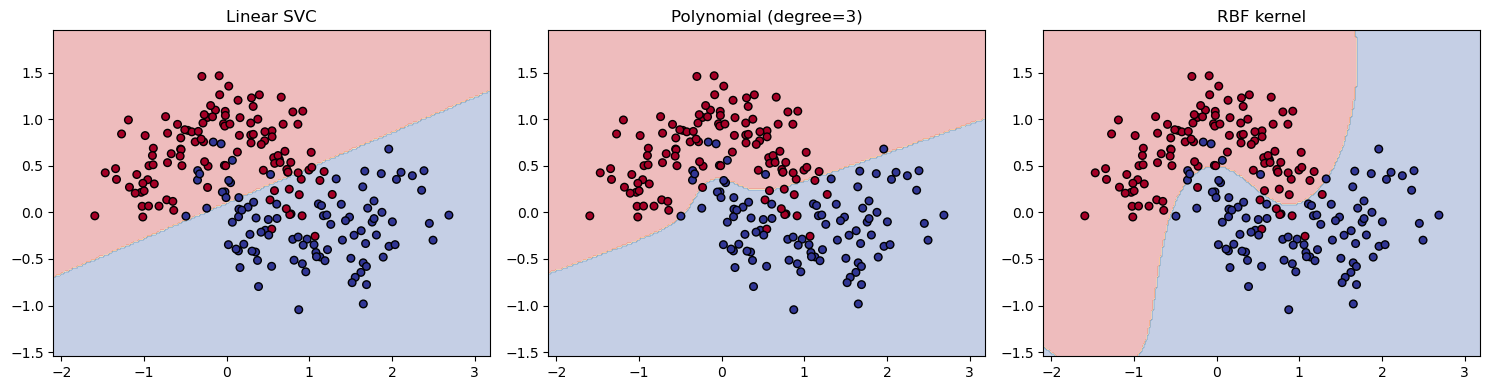

In [3]:
# ================================================================
# Exercise (4) – Nonlinear Separation & SVM Comparison
# ================================================================


# 1) Generate nonlinear two-class data (clearly not linearly separable)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2) Fit SVM models with different kernels
svm_linear = SVC(kernel="linear", C=1).fit(X_train, y_train)
svm_poly   = SVC(kernel="poly", degree=3, C=1).fit(X_train, y_train)
svm_rbf    = SVC(kernel="rbf", gamma=1, C=1).fit(X_train, y_train)

# 3) Compute training & test accuracies
models = {
    "Linear SVC": svm_linear,
    "Polynomial (degree=3)": svm_poly,
    "RBF kernel": svm_rbf
}

results = []
for name, mdl in models.items():
    train_acc = accuracy_score(y_train, mdl.predict(X_train))
    test_acc = accuracy_score(y_test, mdl.predict(X_test))
    results.append((name, train_acc, test_acc))

results_df = pd.DataFrame(results, columns=["Model","Train Accuracy","Test Accuracy"])
display(results_df)

# 4) Plot decision boundaries for each model
def plot_decision_boundary(model, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.3)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor="k", s=30)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, mdl) in zip(axes, models.items()):
    plot_decision_boundary(mdl, X_train, y_train, ax, name)

plt.tight_layout()
plt.show()


**Comments**

- The **linear SVM** (accuracy ≈ 0.84 train / 0.89 test) produces a straight decision boundary that clearly fails to capture the curved structure of the data. It separates the classes roughly but leaves many points on the wrong side of the boundary, evidencing **underfitting**.  

- The **polynomial kernel (degree = 3)** slightly improves the boundary’s flexibility (≈ 0.89 train / 0.89 test), bending along the data structure but still missing the complex curvature between the two clusters. Its performance remains close to the linear model.  

- The **RBF kernel** achieves the best fit (≈ 0.91 train / 0.91 test), with a smooth, nonlinear boundary that closely follows the true separation between the two moon-shaped classes. The nearly identical training and test accuracies indicate **good generalization** without overfitting.  

**Conclusion:**  
The results confirm that kernel-based SVMs outperform the linear SVC on nonlinear problems.  
While the polynomial kernel provides minor improvement, the **RBF kernel best captures the nonlinear pattern**, offering the lowest classification error and the most accurate decision boundary.
